In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

import pyproximal

plt.close("all")

In [2]:
def rosenbrock(x, y, a=1, b=10):
    f = (a - x) ** 2 + b * (y - x**2) ** 2
    return f


def rosenbrock_grad(x, y, a=1, b=10):
    dfx = -2 * (a - x) - 2 * b * (y - x**2) * 2 * x
    dfy = 2 * b * (y - x**2)
    return dfx, dfy


def contour_rosenbrock(x, y):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Evaluate the function
    x, y = np.meshgrid(x, y)
    z = rosenbrock(x, y)

    # Plot the surface.
    surf = ax.contour(
        x, y, z, 200, cmap="gist_heat_r", vmin=-20, vmax=200, antialiased=False
    )
    fig.colorbar(surf, shrink=0.5, aspect=10)
    return fig, ax


class Rosebrock(pyproximal.proximal.Nonlinear):
    def setup(self, a=1, b=10, alpha=1.0):
        self.a, self.b = a, b
        self.alpha = alpha

    def fun(self, x):
        return np.array(rosenbrock(x[0], x[1], a=self.a, b=self.b))

    def grad(self, x):
        return np.array(rosenbrock_grad(x[0], x[1], a=self.a, b=self.b))

    def optimize(self):
        self.solhist = []
        sol = self.x0.copy()
        for iiter in range(self.niter):
            x1, x2 = sol
            dfx1, dfx2 = self._gradprox(sol, self.tau)
            x1 -= self.alpha * dfx1
            x2 -= self.alpha * dfx2
            sol = np.array([x1, x2])
            self.solhist.append(sol)
        self.solhist = np.array(self.solhist)
        return sol

In [3]:
x = np.arange(-1.5, 1.5, 0.15)
y = np.arange(-0.5, 1.5, 0.15)
nx, ny = len(x), len(y)

In [4]:
xbound = np.arange(-1.5, 1.5, 0.01)
ybound = np.arange(-0.5, 1.5, 0.01)
X, Y = np.meshgrid(xbound, ybound, indexing="ij")
xygrid = np.vstack((X.ravel(), Y.ravel()))

lower = 0.6
upper = 1.2
indic = (xygrid > lower) & (xygrid < upper)
indic = indic[0].reshape(xbound.size, ybound.size) & indic[1].reshape(
    xbound.size, ybound.size
)

And using the ADMM solver



In [5]:
fnl = Rosebrock(niter=20, x0=np.array([-1, 1]), warm=False)
fnl.setup(1, 10, alpha=0.02)
ind = pyproximal.proximal.Box(lower, upper)

def callback(x):
    xhist.append(x)

x0 = np.array([0, 0])

xhist = [
    x0,
]
xinv_admm = pyproximal.optimization.primal.ADMM(
    fnl, ind, tau=1.0, x0=x0, niter=30, show=True, callback=callback, gfirst=True
)
xhist_admm0 = np.array(xhist)

ADMM
---------------------------------------------------------
Proximal operator (f): <class '__main__.Rosebrock'>
Proximal operator (g): <class 'pyproximal.proximal.Box.Box'>
tau = 1.000000e+00	niter = 30

   Itn       x[0]          f           g       J = f + g
     1  -2.66102e-01   1.691e+00   0.000e+00   1.691e+00
     2  -1.50575e-01   1.450e+00   0.000e+00   1.450e+00
     3  -4.68638e-02   1.251e+00   0.000e+00   1.251e+00
     4   3.92544e-02   1.096e+00   0.000e+00   1.096e+00
     5   1.05686e-01   9.882e-01   0.000e+00   9.882e-01
     6   1.54334e-01   9.226e-01   0.000e+00   9.226e-01
     7   1.89321e-01   8.903e-01   0.000e+00   8.903e-01
     8   2.15170e-01   8.810e-01   0.000e+00   8.810e-01
     9   2.35698e-01   8.850e-01   0.000e+00   8.850e-01
    10   2.53547e-01   8.947e-01   0.000e+00   8.947e-01
    13   3.01846e-01   9.222e-01   0.000e+00   9.222e-01
    16   3.45642e-01   9.318e-01   0.000e+00   9.318e-01
    19   3.84223e-01   9.275e-01   0.000e+00   9.275

In [6]:
fnl = Rosebrock(niter=20, x0=np.array([-1, 1]), warm=False)
fnl.setup(1, 10, alpha=0.02)
ind = pyproximal.proximal.Box(lower, upper)

def callback(x):
    xhist.append(x)

x0 = np.array([-1, 1])

xhist = [
    x0,
]
xinv_admm = pyproximal.optimization.primal.ADMM(
    fnl, ind, tau=1.0, x0=x0, niter=30, show=True, callback=callback, gfirst=True
)
xhist_admm1 = np.array(xhist)

ADMM
---------------------------------------------------------
Proximal operator (f): <class '__main__.Rosebrock'>
Proximal operator (g): <class 'pyproximal.proximal.Box.Box'>
tau = 1.000000e+00	niter = 30

   Itn       x[0]          f           g       J = f + g
     1  -3.60695e-01   1.980e+00   0.000e+00   1.980e+00
     2  -2.13830e-01   1.655e+00   0.000e+00   1.655e+00
     3  -8.15724e-02   1.382e+00   0.000e+00   1.382e+00
     4   2.59564e-02   1.171e+00   0.000e+00   1.171e+00
     5   1.05242e-01   1.026e+00   0.000e+00   1.026e+00
     6   1.60090e-01   9.415e-01   0.000e+00   9.415e-01
     7   1.97383e-01   9.010e-01   0.000e+00   9.010e-01
     8   2.23742e-01   8.889e-01   0.000e+00   8.889e-01
     9   2.44169e-01   8.918e-01   0.000e+00   8.918e-01
    10   2.61808e-01   9.008e-01   0.000e+00   9.008e-01
    13   3.09489e-01   9.250e-01   0.000e+00   9.250e-01
    16   3.52456e-01   9.319e-01   0.000e+00   9.319e-01
    19   3.90142e-01   9.258e-01   0.000e+00   9.258

In [7]:
class Rosebrock_lbfgs(Rosebrock):
    def optimize(self):
        def callback(x):
            self.solhist.append(x)

        self.solhist = []
        self.solhist.append(self.x0)
        sol = sp.optimize.minimize(
            lambda x: self._funprox(x, self.tau),
            x0=self.x0,
            jac=lambda x: self._gradprox(x, self.tau),
            method="L-BFGS-B",
            callback=callback,
            options=dict(maxiter=15),
        )
        sol = sol.x

        self.solhist = np.array(self.solhist)
        return sol


In [8]:
fnl = Rosebrock_lbfgs(niter=20, x0=np.array([-1, 1]), warm=False)
fnl.setup(1, 10, alpha=0.02)
ind = pyproximal.proximal.Box(lower, upper)

def callback(x):
    xhist.append(x)

x0 = np.array([-1, 1])
xhist = [
    x0,
]
xinv_admm_lbfgs = pyproximal.optimization.primal.ADMM(
    fnl, ind, tau=1.0, x0=x0, niter=30, show=True, callback=callback, gfirst=True
)
xhist_admm_lbfgs1 = np.array(xhist)

ADMM
---------------------------------------------------------
Proximal operator (f): <class '__main__.Rosebrock_lbfgs'>
Proximal operator (g): <class 'pyproximal.proximal.Box.Box'>
tau = 1.000000e+00	niter = 30

   Itn       x[0]          f           g       J = f + g
     1   9.37740e-01   4.251e-03   1.000e+00   1.004e+00
     2   9.47113e-01   2.800e-03   1.000e+00   1.003e+00
     3   9.63219e-01   1.375e-03   1.000e+00   1.001e+00
     4   9.74026e-01   6.867e-04   1.000e+00   1.001e+00
     5   9.81528e-01   3.477e-04   1.000e+00   1.000e+00
     6   9.86771e-01   1.767e-04   1.000e+00   1.000e+00
     7   9.90571e-01   9.027e-05   1.000e+00   1.000e+00
     8   9.93240e-01   4.643e-05   1.000e+00   1.000e+00
     9   9.95162e-01   2.379e-05   1.000e+00   1.000e+00
    10   9.96536e-01   1.221e-05   1.000e+00   1.000e+00
    13   9.98733e-01   1.663e-06   1.000e+00   1.000e+00
    16   9.99916e-01   1.095e-06   1.000e+00   1.000e+00
    19   1.00026e+00   5.430e-07   1.000e+00  

In [9]:
fnl = Rosebrock_lbfgs(niter=20, x0=np.array([-1, 1]), warm=False)
fnl.setup(1, 10, alpha=0.02)
ind = pyproximal.proximal.Box(lower, upper)

def callback(x):
    xhist.append(x)

x0 = np.array([0, 0])
xhist = [
    x0,
]
xinv_admm_lbfgs = pyproximal.optimization.primal.ADMM(
    fnl, ind, tau=1.0, x0=x0, niter=30, show=True, callback=callback, gfirst=True
)
xhist_admm_lbfgs0 = np.array(xhist)

ADMM
---------------------------------------------------------
Proximal operator (f): <class '__main__.Rosebrock_lbfgs'>
Proximal operator (g): <class 'pyproximal.proximal.Box.Box'>
tau = 1.000000e+00	niter = 30

   Itn       x[0]          f           g       J = f + g
     1   8.24627e-01   3.090e-02   1.000e+00   1.031e+00
     2   8.83572e-01   1.382e-02   1.000e+00   1.014e+00
     3   9.17750e-01   6.876e-03   1.000e+00   1.007e+00
     4   9.42749e-01   3.335e-03   1.000e+00   1.003e+00
     5   9.59748e-01   1.648e-03   1.000e+00   1.002e+00
     6   9.71528e-01   8.241e-04   1.000e+00   1.001e+00
     7   9.79789e-01   4.152e-04   1.000e+00   1.000e+00
     8   9.85360e-01   2.174e-04   1.000e+00   1.000e+00
     9   9.89561e-01   1.107e-04   1.000e+00   1.000e+00
    10   9.92539e-01   5.657e-05   1.000e+00   1.000e+00
    13   9.97263e-01   7.639e-06   1.000e+00   1.000e+00
    16   9.99002e-01   1.042e-06   1.000e+00   1.000e+00
    19   1.00011e+00   8.071e-07   1.000e+00  

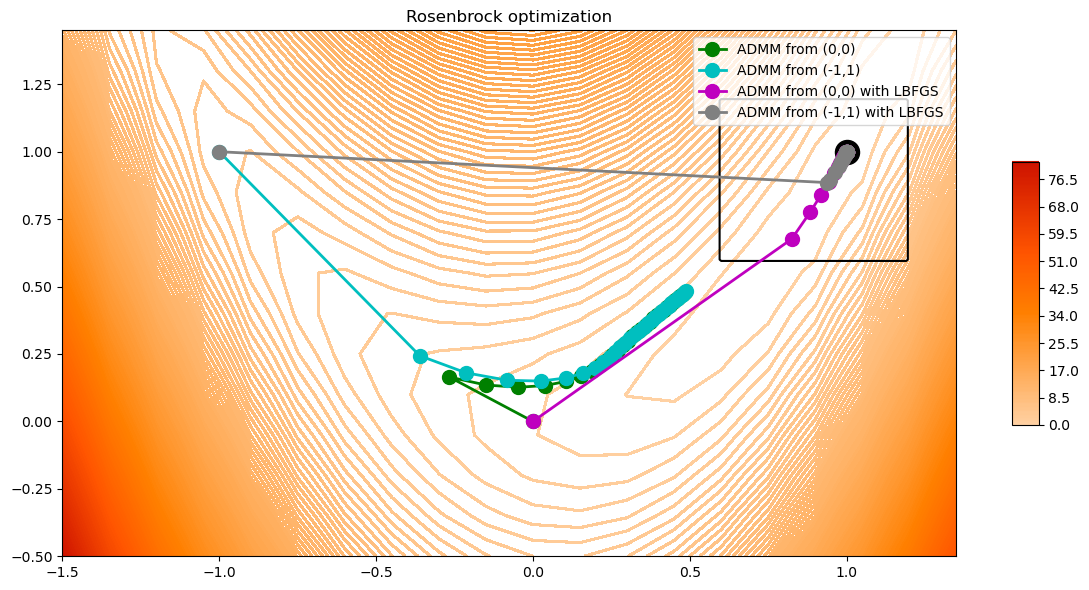

In [10]:
fig, ax = contour_rosenbrock(x, y)
ax.contour(X, Y, indic, colors="k")
ax.scatter(1, 1, c="k", s=300)
ax.plot(xhist_admm0[:, 0], xhist_admm0[:, 1], ".-g", ms=20, lw=2, label="ADMM from (0,0)")
ax.plot(xhist_admm1[:, 0], xhist_admm1[:, 1], ".-c", ms=20, lw=2, label="ADMM from (-1,1)")
ax.plot(
    xhist_admm_lbfgs0[:, 0],
    xhist_admm_lbfgs0[:, 1],
    ".-m",
    ms=20,
    lw=2,
    label="ADMM from (0,0) with LBFGS",
)
ax.plot(
    xhist_admm_lbfgs1[:, 0],
    xhist_admm_lbfgs1[:, 1],
    ".-",
    c="gray",
    ms=20,
    lw=2,
    label="ADMM from (-1,1) with LBFGS",
)
ax.set_title("Rosenbrock optimization")
ax.legend()
ax.set_xlim(x[0], x[-1])
ax.set_ylim(y[0], y[-1])
fig.tight_layout()